In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [3]:
mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

mice = []
session_wide_optimal_lags = []
median_grid_cell_optimal_lags = []
median_non_grid_cell_optimal_lags = []

gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
for mouse, days in mouse_days.items():
    for day in days:
        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, verbose=False, use_optimal_travel=False)
        
        if len(gcs) > 0 and len(ngs) > 0:
            median_grid_cell_optimal_lags.append(gcs['optimal_travel_lag_grid_score'].median())
            median_non_grid_cell_optimal_lags.append(ngs['optimal_travel_lag'].median())
            mice.append(mouse)

        [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, verbose=False)
        gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
        ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
        if len(all) > 0:
            session_travel_lag = all['session_travel_lag'].iloc[0]
            session_wide_optimal_lags.append(session_travel_lag)
            print(f'Mouse {mouse} Day {day} Lag {session_travel_lag}')


Mouse 20 Day 14 Lag 1.8518518518518547
Mouse 20 Day 15 Lag 2.7527527527527553
Mouse 20 Day 16 Lag 11.861861861861868
Mouse 20 Day 17 Lag 6.356356356356358
Mouse 20 Day 18 Lag 10.560560560560567
Mouse 20 Day 19 Lag 5.955955955955957
Mouse 20 Day 20 Lag 4.5545545545545565
Mouse 20 Day 21 Lag -1.4514514514514474
Mouse 20 Day 22 Lag 5.155155155155157
Mouse 20 Day 23 Lag 0.0
Mouse 20 Day 24 Lag 2.552552552552555
Mouse 20 Day 25 Lag 6.356356356356358
Mouse 20 Day 26 Lag 8.85885885885886
Mouse 21 Day 15 Lag 3.1531531531531556
Mouse 21 Day 16 Lag 10.360360360360367
Mouse 21 Day 17 Lag 10.260260260260267
Mouse 21 Day 18 Lag 8.85885885885886
Mouse 21 Day 19 Lag 9.959959959959967
Mouse 21 Day 20 Lag 10.560560560560567
Mouse 21 Day 21 Lag 6.456456456456458
Mouse 21 Day 22 Lag 0.0
Mouse 21 Day 23 Lag 7.157157157157158
Mouse 21 Day 24 Lag 12.062062062062068
Mouse 21 Day 25 Lag 9.35935935935936
Mouse 21 Day 26 Lag 7.057057057057058
Mouse 25 Day 16 Lag -10.76076076076076
Mouse 25 Day 17 Lag 21.3713713

In [4]:
print(f"Total number of GC cells: {len(gcs_)}")
print(f"Total number of NGS cells: {len(ngs_)}")
print(f'Total number of reference cells: {len(gcs_) + len(ngs_)}')

Total number of GC cells: 462
Total number of NGS cells: 5597
Total number of reference cells: 6059


every NGS, and GC cell will be used as a reference cell

it can either have a training set with NGS cells, cmGC or ncmGC
it can either have the ordering mode as nearest, farthest or random


I need to write a script that will submit all the jobs, and keep track of which jobs have been submitted 

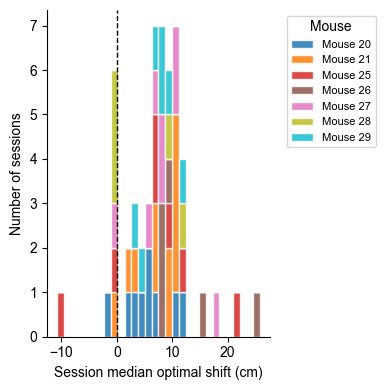

In [5]:
# Only use the subset where both mice and session_wide_optimal_lags were appended together
mice_arr = np.array(mice)
lags_arr = np.array([
    lag for i, lag in enumerate(session_wide_optimal_lags)
    if i < len(mice)
])
unique_mice = np.unique(mice_arr)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_mice)))
color_map = {mouse: colors[i] for i, mouse in enumerate(unique_mice)}
lags_by_mouse = [lags_arr[mice_arr == mouse] for mouse in unique_mice]
labels = [f"Mouse {mouse}" for mouse in unique_mice]
mouse_colors = [color_map[mouse] for mouse in unique_mice]

fig, ax = plt.subplots(figsize=(4, 4))
n, bins, patches = ax.hist(
    lags_by_mouse,
    bins=30,
    stacked=True,
    color=mouse_colors,
    edgecolor="white",
    alpha=0.85,
    label=labels
)
ax.set_xlabel('Session median optimal shift (cm)', fontsize=10)
ax.set_ylabel('Number of sessions', fontsize=10)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=8, title="Mouse", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

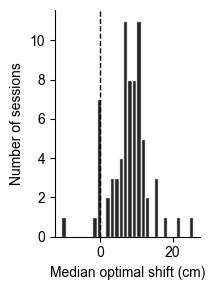

In [6]:
fig, ax = plt.subplots(figsize=(2.2, 3))
ax.hist(session_wide_optimal_lags, bins=30, color="#000000", edgecolor="white", alpha=0.85)
ax.set_xlabel('Median optimal shift (cm)', fontsize=10)
ax.set_ylabel('Number of sessions', fontsize=10)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/session_wide_optimal_lags_histogram.pdf', dpi=300)
plt.show()

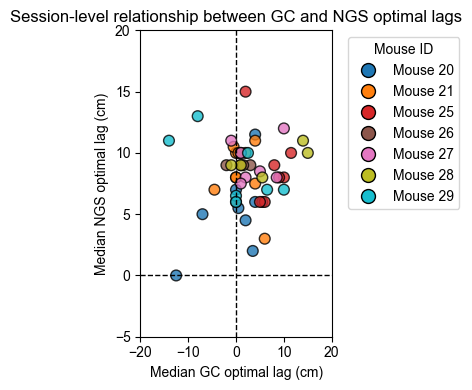

In [7]:
import matplotlib.pyplot as plt
import numpy as np

mice_arr = np.array(mice)
x = np.array(median_grid_cell_optimal_lags)
y = np.array(median_non_grid_cell_optimal_lags)

# Assign a color to each mouse_id
unique_mice = np.unique(mice_arr)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_mice)))
color_map = {mouse: colors[i] for i, mouse in enumerate(unique_mice)}
point_colors = [color_map[m] for m in mice_arr]

fig, ax = plt.subplots(figsize=(4, 4))
scatter = ax.scatter(x, y, c=point_colors, s=60, edgecolor='k', alpha=0.8)

# Create legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markeredgecolor='k', markersize=10, label=f'Mouse {m}')
    for m in unique_mice
]
ax.legend(handles=handles, title='Mouse ID', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Median GC optimal lag (cm)')
ax.set_ylabel('Median NGS optimal lag (cm)')
ax.set_xlim([-20, 20])
ax.set_ylim([-5, 20])
ax.set_title('Session-level relationship between GC and NGS optimal lags')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

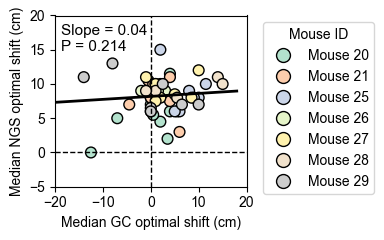

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

mice_arr = np.array(mice)
x = np.array(median_grid_cell_optimal_lags)
y = np.array(median_non_grid_cell_optimal_lags)

# Assign a color to each mouse_id using Pastel2 (avoiding red/blue)
unique_mice = np.unique(mice_arr)
pastel2 = plt.cm.get_cmap('Pastel2', len(unique_mice))
colors = [pastel2(i) for i in range(len(unique_mice))]
color_map = {mouse: colors[i] for i, mouse in enumerate(unique_mice)}
point_colors = [color_map[m] for m in mice_arr]

# Prepare DataFrame for mixed model
df = pd.DataFrame({
    'median_gc': x,
    'median_ngs': y,
    'mouse': mice_arr
})

# Fit linear mixed effect model: median_ngs ~ median_gc + (1|mouse)
model = smf.mixedlm("median_ngs ~ median_gc", df, groups=df["mouse"])
result = model.fit()
slope = result.params['median_gc']
pval = result.pvalues['median_gc']

# Plot
fig, ax = plt.subplots(figsize=(4, 2.5))
scatter = ax.scatter(x, y, c=point_colors, s=60, edgecolor='k', alpha=1)

# Regression line (fixed effect only)
xfit = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)
yfit = result.params['Intercept'] + result.params['median_gc'] * xfit
ax.plot(xfit, yfit, color='k', lw=2, linestyle='-', label='LMM fit')

# Create legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[m], markeredgecolor='k', markersize=10, label=f'Mouse {m}')
    for m in unique_mice
]
ax.legend(handles=handles, title='Mouse ID', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel('Median GC optimal shift (cm)')
ax.set_ylabel('Median NGS optimal shift (cm)')
ax.set_xlim([-20, 20])
ax.set_ylim([-5, 20])
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Annotate slope and p-value
ax.text(
    0.03, 0.95,
    f"Slope = {slope:.2f}\nP = {pval:.3g}",
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    ha='left',
)

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_2_predictive_coding/median_gc_vs_median_ngs_optimal_lags_LMMfit.pdf', dpi=300)
plt.show()